In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import gpflow as gpf 
import numpy as np
import scipy.stats as ss
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm
import os

import sys
sys.path.append("../..")

from atmodel import AdaptiveTransferGPR, ConditionalMOGP, SparseCMOGP
from atkernel import TransferKernel, TransferCoregion
from atlikelihood import TransferLikelihood

def safe_float_conversion(v):
    try:
        v = float(v)
        return v
    except ValueError:
        return np.nan

ihepc = pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False)
ihepc["Datetime"] = ihepc["Date"] + " "+ ihepc["Time"]
ihepc["Datetime"] = pd.to_datetime(ihepc["Datetime"])
ihepc.index = ihepc.Datetime
ihepc_weekly = ihepc["Global_active_power"].map(safe_float_conversion).resample("W").mean().bfill()
power_weekly = (ihepc_weekly - ihepc_weekly.mean()) / ihepc_weekly.std()

2026-05-05 10:11:30.248784: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 10:11:30.252278: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 10:11:30.314850: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-05 10:11:30.315813: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 10:11:31.428045: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT

In [2]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(14, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    plt.plot(Ax, Ay, "x", color="C0", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, "C0", "Y1")

    plt.plot(Bx, By, "x",color="C1", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, "C1", "Y2")
    plt.xlim([0, Ax[:,0].max()])
    plt.ylim([-5, 5])
    try:
        ivs = m.inducing_variable.Z.numpy() 
        plt.scatter(ivs, np.zeros_like(ivs)+2, marker="|", c=m.inducing_indices)
    except AttributeError:
        pass
    plt.legend()
    return mu


def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()
 

In [3]:
weather = pd.read_csv("export.csv")
weather["date"] = pd.to_datetime(weather["date"])
weather.head()
weather.index = weather.date
weather_daily = weather.tavg.bfill().resample("D").mean()
weather_daily = (weather_daily - weather_daily.mean())/weather_daily.std()

207 1461


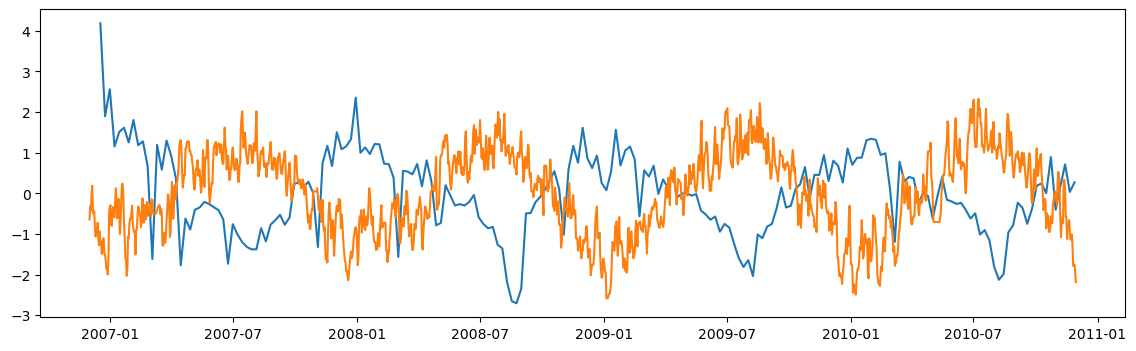

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
print(len(ihepc_weekly), len(weather_daily))
plt.plot(power_weekly)
plt.plot(weather_daily)
plt.show()

In [5]:
Bx = power_weekly.index.view("int64").reshape(-1, 1).astype(float)
By = power_weekly.values.reshape(-1, 1).astype(np.float64)
Ax = weather_daily.index.view("int64").reshape(-1, 1).astype(float)
Ay = weather_daily.values.reshape(-1, 1).astype(np.float64)
n_test = 4
Xtest, ytest = Bx[-n_test:], By[-n_test:]
print(Bx.shape, By.shape)
Bx, By = Bx[:-n_test,:], By[:-n_test,:]
print(Bx.shape, By.shape)
print(len(Xtest), len(ytest))
Xtest = (Xtest - Bx.min()) /(Bx.max() - Bx.min())
Ax = (Ax - Bx.min()) /(Bx.max() - Bx.min())
Bx = (Bx - Bx.min()) /(Bx.max() - Bx.min())
print(Ax.shape, Ay.shape, Bx.shape, By.shape)

X = np.vstack((np.hstack((Ax, np.zeros_like(Ax, dtype=np.int32))), np.hstack((Bx, np.ones_like(Bx, dtype=np.int32)))))
y = np.vstack((np.hstack((Ay, np.zeros_like(Ay, dtype=np.int32))), np.hstack((By, np.ones_like(By, dtype=np.int32)))))
Xtest = np.hstack((Xtest, np.ones_like(Xtest)))


(207, 1) (207, 1)
(203, 1) (203, 1)
4 4
(1461, 1) (1461, 1) (203, 1) (203, 1)


tf.Tensor(-284.2708450074964, shape=(), dtype=float64)
╒════════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════╕
│ name                                                   │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value   │
╞════════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].base_kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0     │
├────────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].base_kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.0     │
├────────────────────────────────────────────────────────┼───────────┼─────

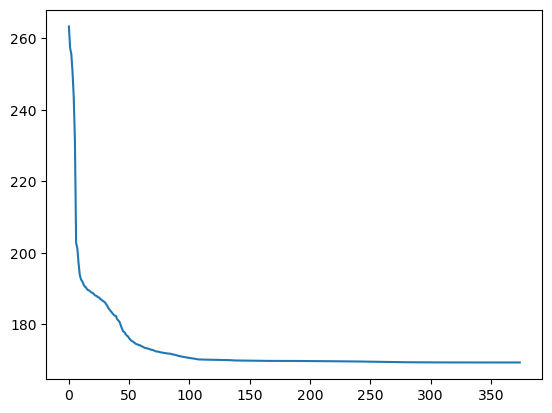

╒════════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤══════════╤═════════╤═════════════════════╕
│ name                                                   │ class     │ transform        │ prior   │ trainable   │ shape    │ dtype   │ value               │
╞════════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪══════════╪═════════╪═════════════════════╡
│ SparseCMOGP.kernel.kernels[0].base_kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 1.69131             │
├────────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼──────────┼─────────┼─────────────────────┤
│ SparseCMOGP.kernel.kernels[0].base_kernel.lengthscales │ Parameter │ Softplus         │         │ True        │ ()       │ float64 │ 0.29061567815637196 │
├────────────────────────────────────────────────────────┼

In [6]:
output_dim = 2 # Number of outputs
k = gpf.kernels.Periodic(gpf.kernels.Matern12())
k2 = gpf.kernels.Periodic(gpf.kernels.Matern12())
# Base kernel

# Coregion kernel
coreg1 = gpf.kernels.Coregion(output_dim=output_dim, rank=1, active_dims=[1])
ivs = np.linspace(0, max(Xtest[:,0]), 200).reshape(-1, 1)
iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
iv_ind = iv_ind[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg1
m = SparseCMOGP((X, y), exact_target=False, kernel=kern, jitter=1e-2, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#m = ConditionalMOGP((X, y), kernel=kern, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))
#gpf.set_trainable(m.kernel.kernels[0].variance, True)
#gpf.set_trainable(m.inducing_variable.Z, False)

print(m.maximum_log_likelihood_objective())

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)


tf.Tensor(
[[0.76710804]
 [0.84174574]
 [0.89578409]
 [0.9293344 ]], shape=(4, 1), dtype=float64)


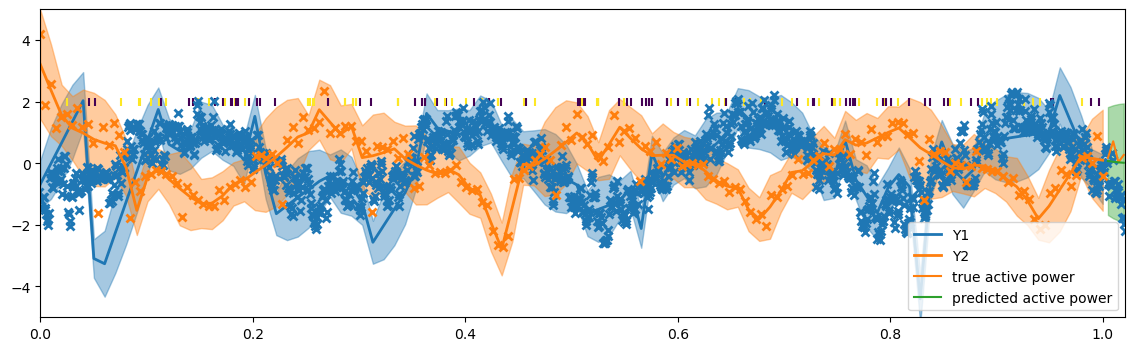

0.12915011663270115


In [7]:
plot(m)
mu, var = m.predict_f(Xtest)
print(var)
plt.plot(Xtest[:,0], ytest, color="C1", label="true active power")
plt.plot(Xtest[:,0], mu, color="C2", label="predicted active power")
plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))


In [10]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Periodic(gpf.kernels.Matern12(), period=0.25)


# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)
probs = np.array([0.5, 0.5])
ivs = np.linspace(0, max(X[:,0]), 100).reshape(-1, 1)
iv_ind = np.random.choice(np.array([0, 1]).astype(np.int32), p=probs, size=len(ivs)).reshape(-1, 1)
ivs = np.hstack((ivs, iv_ind))
# now build the GP model as normal
m = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=ivs)
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)),
    m.trainable_variables,
    method="L-BFGS-B",
)

2026-05-05 10:36:41.009891: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-05-05 10:36:41.075501: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 1567.9835834446294
        x: [-3.640e-01 -2.633e+00 ... -1.171e+00  1.654e+00]
      nit: 841
      jac: [ 2.833e+01  1.466e+01 ... -7.659e+01  1.171e+01]
     nfev: 1266
     njev: 1266
 hess_inv: <5359x5359 LbfgsInvHessProduct with dtype=float64>

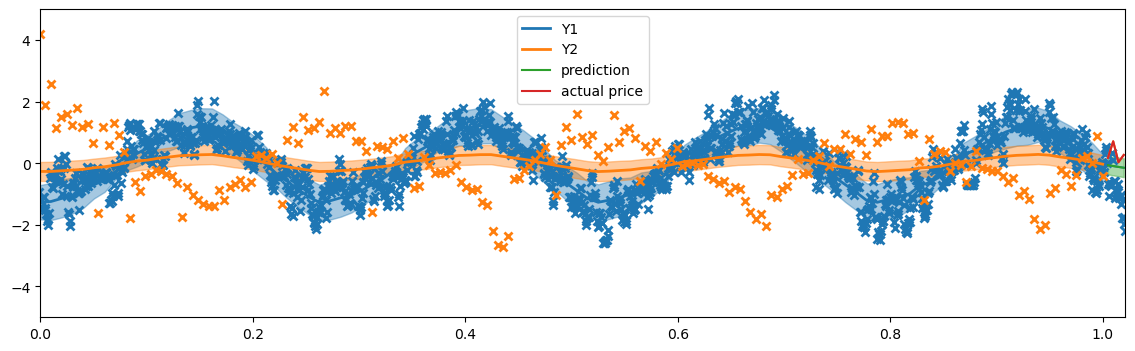

0.22438117519697037


In [11]:
plot(m)
mu, var = m.predict_f(Xtest)
plt.plot(Xtest[:,0], mu)
plt.plot(Xtest[:,0], ytest)
plt.plot(Xtest[:,0], mu, label="prediction")
plt.plot(Xtest[:,0], ytest, label="actual price")
plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))

In [ ]:
sample_X1 = np.linspace(0, 3, 200).reshape(-1, 1)
sample_X2 = np.linspace(0, 3, 50).reshape(-1, 1)
sample_y1 = np.sin(5*sample_X1).reshape(-1, 1) + np.random.normal(0, 0.1, sample_X1.shape[0]).reshape(-1, 1)
sample_y2 = np.sin(7*sample_X2).reshape(-1, 1) + np.random.normal(0, 0.1, sample_X2.shape[0]).reshape(-1, 1)

X = np.vstack((np.hstack((sample_X1, np.zeros_like(sample_X1, dtype=np.int32))), np.hstack((sample_X2, np.ones_like(sample_X2, dtype=np.int32)))))
y = np.vstack((np.hstack((sample_y1, np.zeros_like(sample_y1, dtype=np.int32))), np.hstack((sample_y2, np.ones_like(sample_y2, dtype=np.int32)))))

output_dim = 2  # Number of outputs
rank = 1  # Rank of W

# Base kernel
k = gpf.kernels.Cosine()

# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

kern = k * coreg

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)
probs = np.array([0.5, 0.5])
ivs = np.linspace(0, 3, 4).reshape(-1, 1)
iv_ind = np.random.choice(np.array([0, 1]).astype(np.int32), p=probs, size=len(ivs)).reshape(-1, 1)
ivs = np.hstack((ivs, iv_ind))
# now build the GP model as normal
m = gpf.models.VGP((X, y), kernel=kern, likelihood=lik)#), num_data=len(X), inducing_variable=ivs)
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss,
    m.trainable_variables,
    method="L-BFGS-B",
)

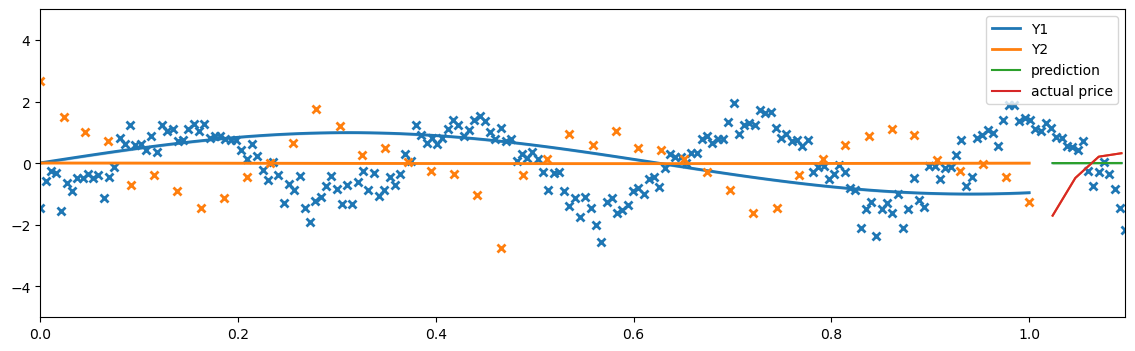

0.8218912460487832


In [ ]:
plot(m)
mu, var = m.predict_f(Xtest)
plt.plot(Xtest[:,0], mu)
plt.plot(Xtest[:,0], ytest)
plt.plot(Xtest[:,0], mu, label="prediction")
plt.plot(Xtest[:,0], ytest, label="actual price")
plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))